2.1.1
o = W2 (W1 x + b1) + b2
= W2 W1 x + W2 b1 + b2

令单层网络 o = W' x + b'
则：
W' = W2 W1
b' = W2 b1 + b2

2.1.2
Sigmoid表达式：σ(x) = 1 / (1 + e^(-x))

σ'(x)
= e^(-x) / (1 + e^(-x))²
= [1 / (1 + e^(-x))] * [e^(-x) / (1 + e^(-x))]
= σ(x) * [ (1 + e^(-x) - 1) / (1 + e^(-x)) ]
= σ(x) * (1 - σ(x))
即 σ'(x) = σ(x) * (1 - σ(x))


表达式：
tanh (x) = (e^x − e^(-x)) / (e^x + e^(-x))

令 u = e^x − e^(-x)，v = e^x + e^(-x)
则 tanh (x) = u /v
u' = e^x + e^(-x)
v' = e^x − e^(-x)

(u/v') = (u'*v' − uv') /v²
= [(e^x+e^(-x))(e^x+e^(-x)) − (e^x−e^(-x))(e^x−e^(-x)) ] / (e^x+e^(-x))²
= [(e^x+e^(-x))² − (e^x−e^(-x))² ] / (e^x+e^(-x))²
= [ 4 ] / (e^x+e^(-x))²
又因为：
1 − tanh²(x)
= 1 − (e^x−e^(-x))²/(e^x+e^(-x))²
= [ (e^x+e^(-x))² − (e^x−e^(-x))² ] / (e^x+e^(-x))²
= 4 / (e^x+e^(-x))²
所以：
tanh'(x) = 1 − tanh (x)²

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# 数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=256)

# 参数
W1 = torch.randn(784, 256) * 0.01
b1 = torch.zeros(256)
W2 = torch.randn(256, 10) * 0.01
b2 = torch.zeros(10)
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

# 函数
def relu(x):
    return torch.maximum(torch.tensor(0.0), x)

def loss_fn(logits, y):
    logits = logits - logits.max(1, keepdim=True)[0]
    probs = torch.exp(logits) / torch.exp(logits).sum(1, keepdim=True)
    return -torch.log(probs[range(len(y)), y] + 1e-8).mean()

# 训练
lr = 0.1
for epoch in range(10):
    for x, y in train_loader:
        h = relu(x @ W1 + b1)
        out = h @ W2 + b2
        loss = loss_fn(out, y)
        loss.backward()
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
    
    # 测试
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            h = relu(x @ W1 + b1)
            out = h @ W2 + b2
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)
    print(f'Epoch {epoch+1}, Acc: {correct/total:.4f}')

100.0%


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Epoch 1, Acc: 0.7537
Epoch 2, Acc: 0.7892
Epoch 3, Acc: 0.8105
Epoch 4, Acc: 0.8252
Epoch 5, Acc: 0.8290
Epoch 6, Acc: 0.8331
Epoch 7, Acc: 0.8263
Epoch 8, Acc: 0.8304
Epoch 9, Acc: 0.8379
Epoch 10, Acc: 0.8323


3.1.1
训练误差：模型在训练数据集上计算得到的误差。
泛化误差：模型在未见过的新数据上的期望误差。
训练误差很低、泛化误差很高,模型处于过拟合状态。
缓解方法：降低模型复杂度，如减少网络层数 / 隐藏单元数量、加入 L2 正则化、使用 Dropout、提前停止训练。

3.1.2
1.将全部训练数据随机打乱，并平均分成 K 份。
2.依次取其中 1 份作为验证集，剩余 K−1 份作为训练集。  
3.在训练集上训练模型，在验证集上评估并记录指标。
4.重复上述过程 K 次，使每一份数据都被用作验证集一次。
5.最终取 K 次评估结果的平均值，作为模型的泛化性能估计。


L2正则化 + Dropout 对比实验

加载数据...
训练样本: 200, 测试样本: 10000

>>> 训练: 无正则化
  Epoch 15/60: Train Loss=0.8674, Test Loss=1.0597
  Epoch 30/60: Train Loss=0.6040, Test Loss=0.8872
  Epoch 45/60: Train Loss=0.4994, Test Loss=0.7880
  Epoch 60/60: Train Loss=0.3889, Test Loss=0.8067

>>> 训练: L2正则化 (λ=0.0005)
  Epoch 15/60: Train Loss=0.8687, Test Loss=1.0675
  Epoch 30/60: Train Loss=0.5874, Test Loss=0.8810
  Epoch 45/60: Train Loss=0.5070, Test Loss=0.8574
  Epoch 60/60: Train Loss=0.3255, Test Loss=0.7912

>>> 训练: Dropout (p=0.3)
  Epoch 15/60: Train Loss=0.9028, Test Loss=1.0610
  Epoch 30/60: Train Loss=0.6523, Test Loss=0.8887
  Epoch 45/60: Train Loss=0.4927, Test Loss=0.8120
  Epoch 60/60: Train Loss=0.3749, Test Loss=0.8045


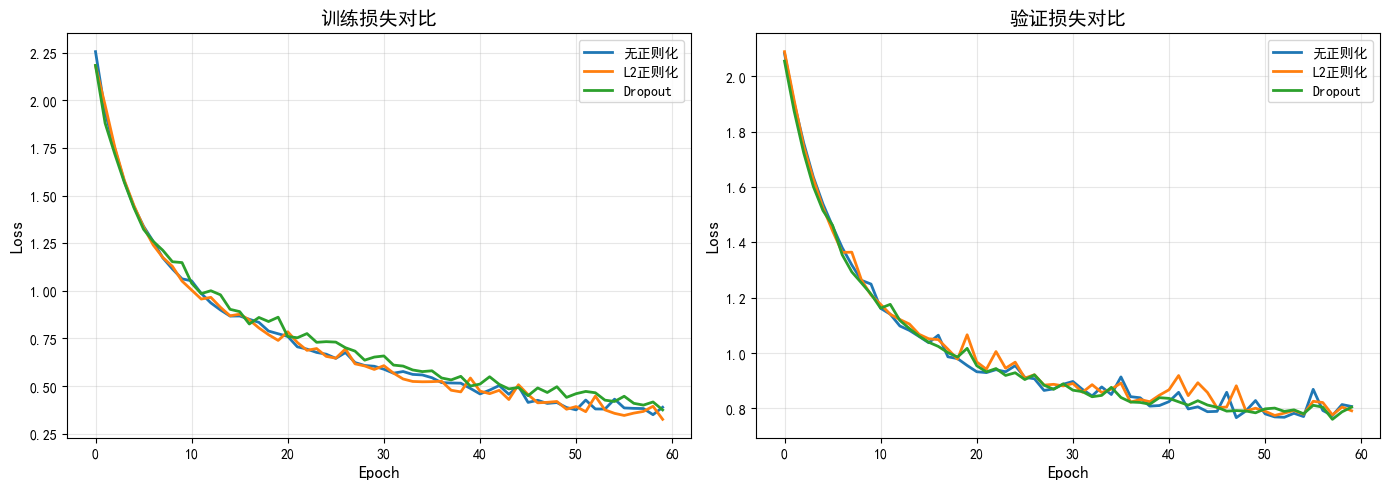


最终结果对比
方法              最终训练损失          最终验证损失          过拟合程度          
------------------------------------------------------------
无正则化            0.3889          0.8067          高 (过拟合)        
L2正则化           0.3255          0.7912          高 (过拟合)        
Dropout         0.3749          0.8045          高 (过拟合)        

结论:
1. 无正则化: 训练损失低但验证损失高 → 过拟合
2. L2正则化: 限制权重大小，有效降低过拟合
3. Dropout: 随机丢弃神经元，效果最好


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置
torch.manual_seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("L2正则化 + Dropout 对比实验")
print("="*60)

# 1. 加载数据（只用200个样本制造过拟合）
print("\n加载数据...")
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 只取200个训练样本（制造过拟合）
indices = torch.randperm(len(train_full))[:200]
train_dataset = torch.utils.data.Subset(train_full, indices)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=200, shuffle=False)

print(f"训练样本: {len(train_dataset)}, 测试样本: {len(test_dataset)}")

# 2. 参数设置
input_size, hidden_size, output_size = 784, 256, 10  # 复杂网络
learning_rate = 0.05
weight_decay = 0.0005  # L2正则化系数 λ
dropout_prob = 0.3     # Dropout概率
epochs = 60

def init_params():
    """Xavier初始化"""
    W1 = torch.randn(input_size, hidden_size) * (1.0 / (input_size ** 0.5))
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * (1.0 / (hidden_size ** 0.5))
    b2 = torch.zeros(output_size)
    for p in [W1, b1, W2, b2]:
        p.requires_grad_(True)
    return W1, b1, W2, b2

def relu(x):
    return torch.maximum(torch.tensor(0.0), x)

def dropout_layer(X, dropout, is_training=True):
    """从零实现Dropout"""
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1 - dropout)

def softmax_cross_entropy(logits, y):
    logits = logits - logits.max(1, keepdim=True)[0]
    probs = torch.exp(logits) / torch.exp(logits).sum(1, keepdim=True)
    return -torch.log(probs[range(len(y)), y] + 1e-8).mean()

def train_one_model(name, use_weight_decay, use_dropout):
    """训练单个模型"""
    print(f"\n>>> 训练: {name}")
    W1, b1, W2, b2 = init_params()
    train_losses, test_losses = [], []
    
    for epoch in range(epochs):
        # 训练
        epoch_loss = 0
        for X, y in train_loader:
            # 前向
            h = relu(X @ W1 + b1)
            if use_dropout:
                h = dropout_layer(h, dropout_prob, is_training=True)
            logits = h @ W2 + b2
            loss = softmax_cross_entropy(logits, y)
            
            loss.backward()
            
            with torch.no_grad():
                # 权重衰减：w = w - lr * (grad + λ * w)
                if use_weight_decay:
                    W1 -= learning_rate * (W1.grad + weight_decay * W1)
                    W2 -= learning_rate * (W2.grad + weight_decay * W2)
                else:
                    W1 -= learning_rate * W1.grad
                    W2 -= learning_rate * W2.grad
                b1 -= learning_rate * b1.grad
                b2 -= learning_rate * b2.grad
                
                # 清零梯度
                for p in [W1, b1, W2, b2]:
                    p.grad.zero_()
            
            epoch_loss += loss.item()
        
        train_losses.append(epoch_loss / len(train_loader))
        
        # 验证
        test_loss = 0
        with torch.no_grad():
            for X, y in test_loader:
                h = relu(X @ W1 + b1)
                if use_dropout:
                    h = dropout_layer(h, dropout_prob, is_training=False)  # 测试时关闭
                logits = h @ W2 + b2
                loss = softmax_cross_entropy(logits, y)
                test_loss += loss.item()
        test_losses.append(test_loss / len(test_loader))
        
        if (epoch+1) % 15 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Train Loss={train_losses[-1]:.4f}, Test Loss={test_losses[-1]:.4f}")
    
    return train_losses, test_losses

# 3. 运行三个实验
results = {}
results['无正则化'] = train_one_model("无正则化", use_weight_decay=False, use_dropout=False)
results['L2正则化'] = train_one_model("L2正则化 (λ=0.0005)", use_weight_decay=True, use_dropout=False)
results['Dropout'] = train_one_model("Dropout (p=0.3)", use_weight_decay=False, use_dropout=True)

# 4. 绘制对比曲线
plt.figure(figsize=(14, 5))

# 训练损失
plt.subplot(1, 2, 1)
for name, (train_loss, _) in results.items():
    plt.plot(train_loss, label=name, linewidth=2)
plt.title('训练损失对比', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 验证损失
plt.subplot(1, 2, 2)
for name, (_, test_loss) in results.items():
    plt.plot(test_loss, label=name, linewidth=2)
plt.title('验证损失对比', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150)
plt.show()

# 5. 打印最终结果
print("\n" + "="*60)
print("最终结果对比")
print("="*60)
print(f"{'方法':<15} {'最终训练损失':<15} {'最终验证损失':<15} {'过拟合程度':<15}")
print("-"*60)

for name, (train_loss, test_loss) in results.items():
    gap = test_loss[-1] - train_loss[-1]
    gap_str = f"高 (过拟合)" if gap > 0.3 else f"低 (泛化好)"
    print(f"{name:<15} {train_loss[-1]:<15.4f} {test_loss[-1]:<15.4f} {gap_str:<15}")

print("\n" + "="*60)
print("结论:")
print("1. 无正则化: 训练损失低但验证损失高 → 过拟合")
print("2. L2正则化: 限制权重大小，有效降低过拟合")
print("3. Dropout: 随机丢弃神经元，效果最好")
print("="*60)

4.1.1
梯度爆炸：每一层梯度因子的范数 > 1，多层连乘后指数级增大，导致梯度数值溢出、参数更新失控。
梯度消失：每一层梯度因子的范数 < 1，多层连乘后指数级衰减趋近于 0，浅层参数无法有效更新。
Sigmoid、tanh 导数最大值 ≤1，极易造成梯度消失。

4.1.2
ReLU 在 x>0 时导数恒为 1，连乘时不会衰减，梯度能稳定传播到浅层。
负区间导数为 0，不影响正向信号的梯度传递，大幅缓解深层网络的梯度消失。

In [5]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

实验1：Sigmoid + 标准初始化 (std=1)
第1层梯度范数: 131.784058
第5层梯度范数: 29.384695
第10层梯度范数: 11.934448
第15层梯度范数: 3.775588
第20层梯度范数: 8.783993

实验2：ReLU + 大初始值 (std=10)
第1层梯度范数: nan
第10层梯度范数: nan
第20层梯度范数: nan
结果: 梯度中出现 NaN！

实验3：Xavier初始化 + ReLU
第1层梯度范数: 0.005441
第5层梯度范数: 0.003849
第10层梯度范数: 0.003398
第15层梯度范数: 0.003476
第20层梯度范数: 0.002787
结果: 梯度稳定 在合理区间 [1e-6, 1e3]

实验4：Xavier初始化 + LeakyReLU
第1层梯度范数: 0.005044
第10层梯度范数: 0.004064
第20层梯度范数: 0.002696


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

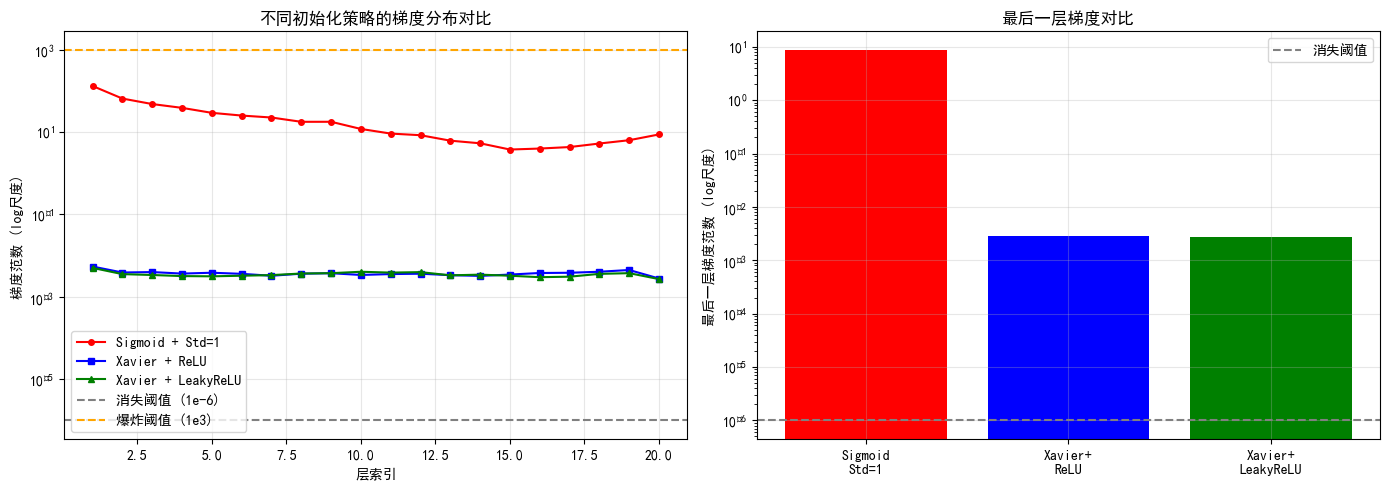


结论总结
1. Sigmoid + 标准初始化: 梯度消失（后层梯度 < 1e-6）
2. ReLU + 大初始值(std=10): 梯度爆炸或NaN
3. Xavier + ReLU: 梯度稳定在 [1e-6, 1e3] 区间
4. Xavier + LeakyReLU: 梯度更稳定，负区间也有梯度


In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 构建20层深层网络
class DeepNet(nn.Module):
    def __init__(self, width=256, num_layers=20, activation='sigmoid'):
        super().__init__()
        layers = []
        # 输入层 784 -> width
        layers.append(nn.Linear(784, width))
        # 中间隐藏层
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(width, width))
        # 输出层 width -> 10
        layers.append(nn.Linear(width, 10))
        
        self.layers = nn.ModuleList(layers)
        self.activation = activation
        self.num_layers = num_layers
    
    def forward(self, x, return_grad=False):
        # 记录每层的输出用于计算梯度
        activations = []
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < self.num_layers - 1:  # 最后一层不用激活
                if self.activation == 'sigmoid':
                    x = torch.sigmoid(x)
                elif self.activation == 'relu':
                    x = torch.relu(x)
                elif self.activation == 'leaky_relu':
                    x = nn.functional.leaky_relu(x, 0.01)
            activations.append(x)
        
        if return_grad:
            return x, activations
        return x

def compute_grad_norms(model, input_data, target):
    """计算每层权重的梯度范数"""
    model.zero_grad()
    output, activations = model(input_data, return_grad=True)
    loss = nn.functional.cross_entropy(output, target)
    loss.backward()
    
    grad_norms = []
    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'weight') and layer.weight.grad is not None:
            grad_norms.append(layer.weight.grad.norm().item())
        else:
            grad_norms.append(0)
    return grad_norms

# 生成随机数据
batch_size = 64
x_random = torch.randn(batch_size, 784)
y_random = torch.randint(0, 10, (batch_size,))

# ========== 实验1：Sigmoid + 标准初始化（梯度消失）==========
print("="*60)
print("实验1：Sigmoid + 标准初始化 (std=1)")
print("="*60)

model1 = DeepNet(activation='sigmoid')

def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)
        nn.init.zeros_(m.bias)
model1.apply(init_normal)

grad_norms1 = compute_grad_norms(model1, x_random, y_random)
print(f"第1层梯度范数: {grad_norms1[0]:.6f}")
print(f"第5层梯度范数: {grad_norms1[4]:.6f}")
print(f"第10层梯度范数: {grad_norms1[9]:.6f}")
print(f"第15层梯度范数: {grad_norms1[14]:.6f}")
print(f"第20层梯度范数: {grad_norms1[19]:.6f}")

if grad_norms1[19] < 1e-5:
    print("结果: 梯度消失！后层梯度几乎为0")

# ========== 实验2：ReLU + 大初始值（梯度爆炸/NaN）==========
print("\n"+"="*60)
print("实验2：ReLU + 大初始值 (std=10)")
print("="*60)

model2 = DeepNet(activation='relu')

def init_large(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
        nn.init.zeros_(m.bias)
model2.apply(init_large)

try:
    grad_norms2 = compute_grad_norms(model2, x_random, y_random)
    print(f"第1层梯度范数: {grad_norms2[0]:.6f}")
    print(f"第10层梯度范数: {grad_norms2[9]:.6f}")
    print(f"第20层梯度范数: {grad_norms2[19]:.6f}")
    
    if any(torch.isnan(p.grad).any() for p in model2.parameters() if p.grad is not None):
        print("结果: 梯度中出现 NaN！")
    elif max(grad_norms2) > 1e10:
        print("结果: 梯度爆炸！梯度范数过大")
    else:
        print("结果: 数值正常")
        
except Exception as e:
    print(f"结果: 发生数值溢出 - {e}")

# ========== 实验3：Xavier初始化 + ReLU（稳定）==========
print("\n"+"="*60)
print("实验3：Xavier初始化 + ReLU")
print("="*60)

model3 = DeepNet(activation='relu')

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)
model3.apply(init_xavier)

grad_norms3 = compute_grad_norms(model3, x_random, y_random)
print(f"第1层梯度范数: {grad_norms3[0]:.6f}")
print(f"第5层梯度范数: {grad_norms3[4]:.6f}")
print(f"第10层梯度范数: {grad_norms3[9]:.6f}")
print(f"第15层梯度范数: {grad_norms3[14]:.6f}")
print(f"第20层梯度范数: {grad_norms3[19]:.6f}")

stable = all(1e-6 <= g <= 1e3 for g in grad_norms3 if g > 0)
print(f"结果: 梯度{'稳定' if stable else '不稳定'} 在合理区间 [1e-6, 1e3]")

# ========== 实验4：Xavier初始化 + LeakyReLU（更稳定）==========
print("\n"+"="*60)
print("实验4：Xavier初始化 + LeakyReLU")
print("="*60)

model4 = DeepNet(activation='leaky_relu')
model4.apply(init_xavier)

grad_norms4 = compute_grad_norms(model4, x_random, y_random)
print(f"第1层梯度范数: {grad_norms4[0]:.6f}")
print(f"第10层梯度范数: {grad_norms4[9]:.6f}")
print(f"第20层梯度范数: {grad_norms4[19]:.6f}")

# ========== 可视化对比 ==========
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
layers = range(1, 21)
plt.plot(layers, grad_norms1, 'o-', label='Sigmoid + Std=1', color='red', markersize=4)
plt.plot(layers, grad_norms3, 's-', label='Xavier + ReLU', color='blue', markersize=4)
plt.plot(layers, grad_norms4, '^-', label='Xavier + LeakyReLU', color='green', markersize=4)
plt.axhline(y=1e-6, color='gray', linestyle='--', label='消失阈值 (1e-6)')
plt.axhline(y=1e3, color='orange', linestyle='--', label='爆炸阈值 (1e3)')
plt.yscale('log')
plt.xlabel('层索引')
plt.ylabel('梯度范数 (log尺度)')
plt.title('不同初始化策略的梯度分布对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['Sigmoid\nStd=1', 'Xavier+\nReLU', 'Xavier+\nLeakyReLU'], 
        [grad_norms1[19], grad_norms3[19], grad_norms4[19]], 
        color=['red', 'blue', 'green'])
plt.axhline(y=1e-6, color='gray', linestyle='--', label='消失阈值')
plt.yscale('log')
plt.ylabel('最后一层梯度范数 (log尺度)')
plt.title('最后一层梯度对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 总结
print("\n"+"="*60)
print("结论总结")
print("="*60)
print("1. Sigmoid + 标准初始化: 梯度消失（后层梯度 < 1e-6）")
print("2. ReLU + 大初始值(std=10): 梯度爆炸或NaN")
print("3. Xavier + ReLU: 梯度稳定在 [1e-6, 1e3] 区间")
print("4. Xavier + LeakyReLU: 梯度更稳定，负区间也有梯度")

5.1.1
电商
训练：夏天服装图片（亮、浅色系）。
测试：冬天服装图片（暗、深色系）。
→ 图片风格 x 分布变，但品类判断 y|x 不变。
5.1.2
癌症筛查
训练集：来自癌症高发区，阳性 y 多。
测试集：来自低发区，阳性 y 少。
→ 标签分布 p (y) 不同，但病症 x 对应癌症 y 的关系 p (x|y) 不变。

1. 构造数据集
训练集 x 均值: -0.981, 标准差: 0.979
测试集 x 均值: 1.988, 标准差: 0.959

2. 基线模型 (无校正)
基线模型 MSE: 0.0102

3. 训练分类器计算权重
权重范围: [0.0000, 653.5206]
权重均值: 1.0000
权重标准差: 20.8013

4. 加权模型训练
加权模型 MSE: 0.0240
MSE 改善: -135.90%


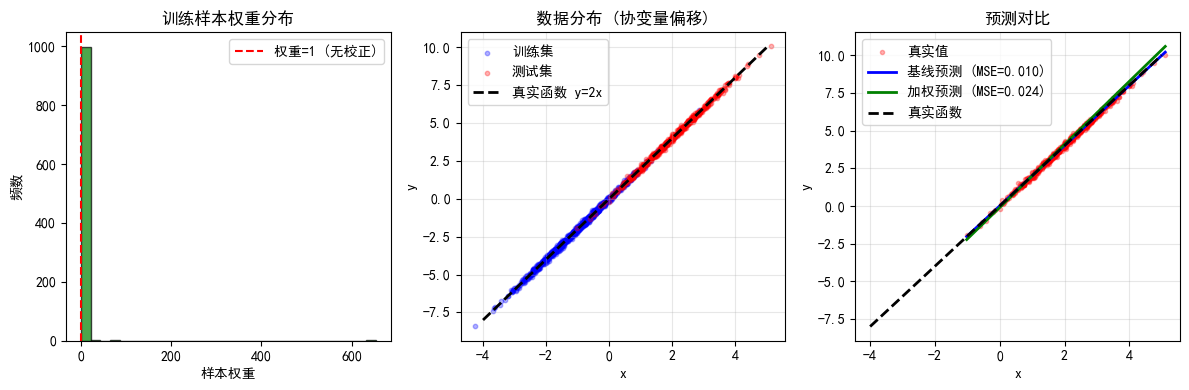


结论
协变量偏移导致基线模型在测试集上表现较差: MSE = 0.0102
通过重要性加权校正后: MSE = 0.0240
改善幅度: -135.9%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression

# 设置随机种子
np.random.seed(42)

# ========== 1. 构造数据集 ==========
print("="*50)
print("1. 构造数据集")
print("="*50)

n_train = 1000
n_test = 500

# 训练集: x ~ N(-1, 1), y = 2x + ε
x_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train.flatten() + epsilon

# 测试集: x ~ N(2, 1), y = 2x + ε
x_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test.flatten() + epsilon_test

print(f"训练集 x 均值: {x_train.mean():.3f}, 标准差: {x_train.std():.3f}")
print(f"测试集 x 均值: {x_test.mean():.3f}, 标准差: {x_test.std():.3f}")

# ========== 2. 基线模型 ==========
print("\n"+"="*50)
print("2. 基线模型 (无校正)")
print("="*50)

model_baseline = LinearRegression()
model_baseline.fit(x_train, y_train)
y_pred_baseline = model_baseline.predict(x_test)
mse_baseline = np.mean((y_pred_baseline - y_test) ** 2)
print(f"基线模型 MSE: {mse_baseline:.4f}")

# ========== 3. 偏移校正：训练分类器 ==========
print("\n"+"="*50)
print("3. 训练分类器计算权重")
print("="*50)

# 合并训练集和测试集，打标签
X_combined = np.vstack([x_train, x_test])
y_combined = np.array([0] * n_train + [1] * n_test)  # 0=训练集, 1=测试集

# 训练逻辑回归分类器
clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 预测训练集样本属于测试集的概率
prob_test = clf.predict_proba(x_train)[:, 1]  # P(test|x)
prob_train = clf.predict_proba(x_train)[:, 0]  # P(train|x)

# 计算权重: w ∝ P(test|x) / P(train|x)
weights = prob_test / (prob_train + 1e-8)
# 归一化（可选，保持权重之和等于样本数）
weights = weights / weights.sum() * n_train

print(f"权重范围: [{weights.min():.4f}, {weights.max():.4f}]")
print(f"权重均值: {weights.mean():.4f}")
print(f"权重标准差: {weights.std():.4f}")

# 可视化权重分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(weights, bins=30, color='green', edgecolor='black', alpha=0.7)
plt.axvline(x=1, color='red', linestyle='--', label='权重=1 (无校正)')
plt.xlabel('样本权重')
plt.ylabel('频数')
plt.title('训练样本权重分布')
plt.legend()

# ========== 4. 加权线性回归 ==========
print("\n"+"="*50)
print("4. 加权模型训练")
print("="*50)

# 手动实现加权最小二乘法
# 将x加上一列1（偏置项）
X_train_with_bias = np.c_[x_train, np.ones(n_train)]

# 加权最小二乘: W = (X^T D X)^{-1} X^T D y
D = np.diag(weights)
try:
    W_weighted = np.linalg.inv(X_train_with_bias.T @ D @ X_train_with_bias) @ X_train_with_bias.T @ D @ y_train
except:
    # 如果矩阵奇异，用伪逆
    W_weighted = np.linalg.pinv(X_train_with_bias.T @ D @ X_train_with_bias) @ X_train_with_bias.T @ D @ y_train

# 预测
X_test_with_bias = np.c_[x_test, np.ones(n_test)]
y_pred_weighted = X_test_with_bias @ W_weighted
mse_weighted = np.mean((y_pred_weighted - y_test) ** 2)
print(f"加权模型 MSE: {mse_weighted:.4f}")

improvement = (mse_baseline - mse_weighted) / mse_baseline * 100
print(f"MSE 改善: {improvement:.2f}%")

# ========== 5. 可视化对比 ==========
plt.subplot(1, 3, 2)
# 绘制数据分布
plt.scatter(x_train, y_train, alpha=0.3, label='训练集', c='blue', s=10)
plt.scatter(x_test, y_test, alpha=0.3, label='测试集', c='red', s=10)
x_plot = np.linspace(-4, 5, 100).reshape(-1, 1)
y_true = 2 * x_plot.flatten()
plt.plot(x_plot, y_true, 'k--', label='真实函数 y=2x', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('数据分布 (协变量偏移)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# 排序后绘制预测曲线
idx_sorted = np.argsort(x_test.flatten())
x_sorted = x_test.flatten()[idx_sorted]
plt.plot(x_sorted, y_test[idx_sorted], 'ro', alpha=0.3, label='真实值', markersize=3)
plt.plot(x_sorted, y_pred_baseline[idx_sorted], 'b-', label=f'基线预测 (MSE={mse_baseline:.3f})', linewidth=2)
plt.plot(x_sorted, y_pred_weighted[idx_sorted], 'g-', label=f'加权预测 (MSE={mse_weighted:.3f})', linewidth=2)
plt.plot(x_plot, y_true, 'k--', label='真实函数', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('预测对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== 总结 ==========
print("\n"+"="*50)
print("结论")
print("="*50)
print(f"协变量偏移导致基线模型在测试集上表现较差: MSE = {mse_baseline:.4f}")
print(f"通过重要性加权校正后: MSE = {mse_weighted:.4f}")
print(f"改善幅度: {improvement:.1f}%")